Data Successfully Decoded!
Total Wi-Fi Packets (Time Samples): 1859
Raw Matrix Shape: (1859, 30, 3, 2)


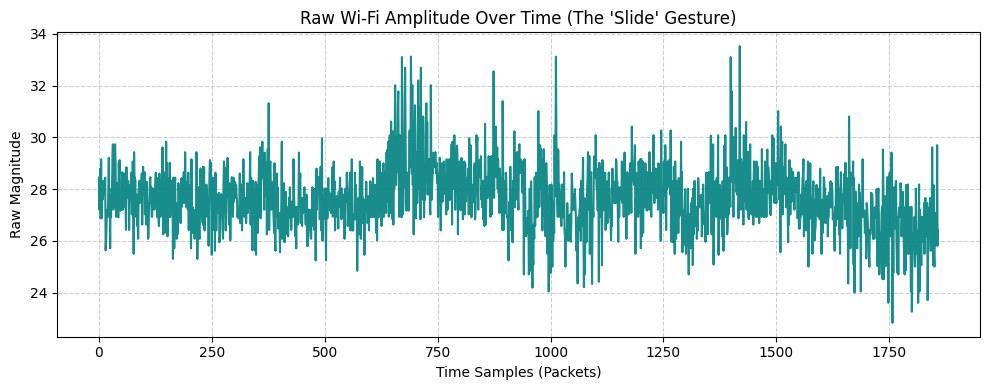

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import csiread

# 1. Initialize the Intel 5300 hardware parser
file_path = 'CSI DATASET/user1-4-1-1-1-r1.dat' # Ensure this matches your exact file name
csidata = csiread.Intel(file_path)

# Parse the binary file
csidata.read()

# 2. Extract the raw complex CSI matrix
# The Intel 5300 shape is: (Packets, Tx_Antennas, Rx_Antennas, Subcarriers)
raw_csi = csidata.csi

print(f"Data Successfully Decoded!")
print(f"Total Wi-Fi Packets (Time Samples): {raw_csi.shape[0]}")
print(f"Raw Matrix Shape: {raw_csi.shape}")

# 3. Isolate a single spatial stream
# We will look at the link between Transmitter 0 and Receiver 0
# We select all time samples (:), Tx=0, Rx=0, and all 30 subcarriers (:)
single_link_csi = raw_csi[:, :, 0, 0] 

# 4. Calculate the Amplitude (Magnitude) from the complex numbers
# This is the physical |H(f, t)| before we apply the sliding window
amplitude = np.abs(single_link_csi)

# 5. Plot the amplitude of a single subcarrier (e.g., Subcarrier 15)
plt.figure(figsize=(10, 4))
plt.plot(amplitude[:, 15], color='teal', alpha=0.9, linewidth=1.5)
plt.title("Raw Wi-Fi Amplitude Over Time (The 'Slide' Gesture)")
plt.xlabel("Time Samples (Packets)")
plt.ylabel("Raw Magnitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [4]:
Nc = 100
Ns = 30
Nf = 8

def create_dual_windows(data_stream):
    first_level_features = []
    
    # Step 1: CSI-Amplitude Window Loop (Section II-B, Step 1)
    for i in range(0, len(data_stream) - Nc, Ns):
        window = data_stream[i : i + Nc]
        
        # Equation 6: Normalization to remove slow fading
        rms = np.sqrt(np.mean(np.square(window)))
        normalized_window = window / rms
        
        # Calculate a basic first-level feature (e.g., Mean)
        first_level_features.append(np.mean(normalized_window))
    
    # Step 2: Feature Window (Section II-B, Step 2)
    final_feature_blocks = []
    for j in range(0, len(first_level_features) - Nf):
        # Stack Nf consecutive features
        feature_block = first_level_features[j : j + Nf]
        final_feature_blocks.append(feature_block)
        
    return np.array(final_feature_blocks)

# Apply to one subcarrier (e.g., index 15)
feature_matrix = create_dual_windows(amplitude[:, 15])
print(f"Feature Matrix Shape: {feature_matrix.shape}")

Feature Matrix Shape: (51, 8)


In [5]:
from scipy.stats import rice

def extract_rician_features(data_stream):
    Nc = 100
    Ns = 30
    Nf = 8
    
    k_factor_series = []
    
    # Step 1: CSI-Amplitude Window Loop (Section II-B)
    for i in range(0, len(data_stream) - Nc, Ns):
        window = data_stream[i : i + Nc]
        
        # Equation 6: Normalization [cite: 136]
        rms = np.sqrt(np.mean(np.square(window)))
        normalized_window = window / rms
        
        # Section II-C: Rician Parameter Estimation via MLE [cite: 239]
        # rice.fit returns (shape, loc, scale). 
        # In WCT, the shape 'v' is related to the K-factor.
        v, loc, scale = rice.fit(normalized_window, floc=0) 
        
        # Calculate K-factor: K = (v^2) / (2 * scale^2) [cite: 207]
        k_factor = (v**2) / (2 * (scale**2))
        k_factor_series.append(k_factor)
    
    # Step 2: Feature Window (Section II-B, Step 2) [cite: 141]
    final_features = []
    for j in range(0, len(k_factor_series) - Nf):
        feature_block = k_factor_series[j : j + Nf]
        final_features.append(feature_block)
        
    return np.array(final_features), np.array(k_factor_series)

# Run the physics extractor
rician_feature_matrix, raw_k_series = extract_rician_features(amplitude[:, 15])

print(f"Rician Feature Matrix Shape: {rician_feature_matrix.shape}")

Rician Feature Matrix Shape: (51, 8)


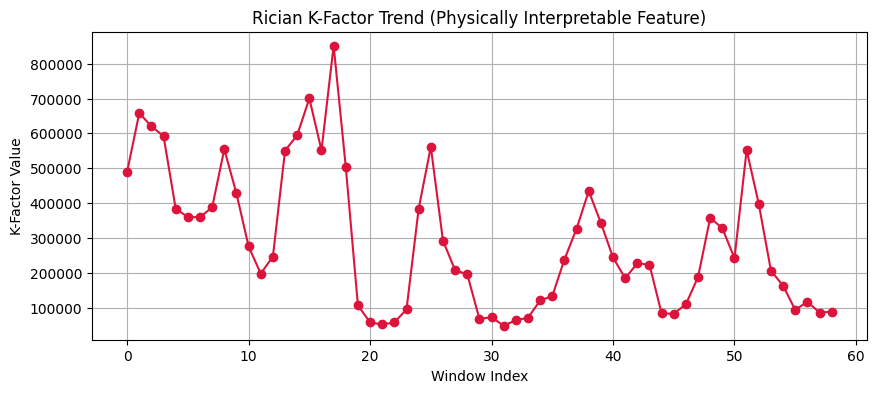

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(raw_k_series, marker='o', color='crimson')
plt.title("Rician K-Factor Trend (Physically Interpretable Feature)")
plt.xlabel("Window Index")
plt.ylabel("K-Factor Value")
plt.grid(True)
plt.show()

In [8]:
from scipy.stats import rice

def extract_all_wct_features(data_stream):
    Nc = 100
    Ns = 30
    Nf = 8
    
    # Storage for our first-level features
    k_series = []
    std_series = []
    par_series = []
    cct_series = []
    
    # Step 1: CSI-Amplitude Window Loop
    for i in range(0, len(data_stream) - Nc, Ns):
        window = data_stream[i : i + Nc]
        
        # --- 1. Raw Amplitude STD ---
        std_series.append(np.std(window))
        
        # --- 2. Peak-to-Average Ratio (PAR) ---
        peak_sq = np.max(window)**2
        rms_sq = np.mean(np.square(window))
        par = peak_sq / rms_sq if rms_sq > 0 else 0
        par_series.append(par)
        
        # --- 3. Channel Coherence Time (CCT Proxy via Autocorrelation) ---
        # We calculate how much the window correlates with a shifted version of itself
        if np.var(window) == 0:
            cct_proxy = 1.0 # Perfectly stable
        else:
            cct_proxy = np.corrcoef(window[:-1], window[1:])[0, 1]
        cct_series.append(cct_proxy)
        
        # --- 4. Rician K-Factor (Equation 6 & MLE) ---
        rms = np.sqrt(rms_sq)
        normalized_window = window / rms
        v, loc, scale = rice.fit(normalized_window, floc=0) 
        k_factor = (v**2) / (2 * (scale**2))
        k_series.append(k_factor)
        
    # Step 2: Feature Window Stacking (Combining everything for the ML model)
    final_features = []
    threshold = np.median(k_series) # For LCR and AFD
    
    for j in range(0, len(k_series) - Nf):
        k_block = np.array(k_series[j : j + Nf])
        
        # LCR and AFD math
        crossings = np.sum((k_block[:-1] >= threshold) & (k_block[1:] < threshold))
        time_below = np.sum(k_block < threshold)
        afd = time_below / crossings if crossings > 0 else time_below
        
        # The Ultimate Feature Vector for this time-step
        feature_vector = [
            np.mean(k_block),                     # 1. Mean K-factor
            np.std(k_block),                      # 2. Variance of K-factor
            crossings,                            # 3. LCR
            afd,                                  # 4. AFD
            np.mean(std_series[j : j + Nf]),      # 5. Mean Raw STD
            np.mean(par_series[j : j + Nf]),      # 6. Mean PAR
            np.mean(cct_series[j : j + Nf])       # 7. Mean CCT (Coherence)
        ]
        final_features.append(feature_vector)
        
    return np.array(final_features)

# Run the upgraded pipeline
advanced_ml_dataset = extract_all_wct_features(amplitude[:, 15])

print(f"Advanced ML Feature Matrix Shape: {advanced_ml_dataset.shape}")
print("Columns: [Mean_K, Std_K, LCR, AFD, Mean_Raw_STD, Mean_PAR, Mean_CCT]")

Advanced ML Feature Matrix Shape: (51, 7)
Columns: [Mean_K, Std_K, LCR, AFD, Mean_Raw_STD, Mean_PAR, Mean_CCT]
